# Full-Stokes flow through a basal slippery patch

The Allan Hills target is a vertical sequence: approximately 5 Ma ice, Pleistocene ice, and older ice from top to bottom. This notebook asks whether vertical shear generated by a localized low-drag bed can overturn initially monotonic layers. It uses a genuine two-dimensional Stokes solve rather than a depth-integrated approximation.

## Mechanical model

I model a 40 km long, 1 km thick parallel-sided slab in coordinates aligned with a surface slope of 0.0025. Velocity $\mathbf{u}=(u,w)$ and pressure $p$ satisfy

$$-\nabla\cdot\left[2\mu\,\mathrm{sym}(\nabla\mathbf{u})-p\mathbf{I}\right]=\rho\mathbf{g},\qquad \nabla\cdot\mathbf{u}=0.$$

The viscosity is constant, $\mu=10^7$ Pa yr (about $3.16\times10^{14}$ Pa s). I use a Taylor–Hood pair: continuous quadratic vector velocity and continuous linear pressure. The bed is impermeable and has Robin traction $\tau_b=-\beta(x)u_t$. The drag falls smoothly from $\beta_0$ to $0.1\beta_0$ across an 8 km patch. The upper surface is traction-free. At the two distant lateral boundaries I impose the analytical velocity profile of the uniform background slab; no interior velocity is prescribed.

The Stokes calculation is an instantaneous patch-centered snapshot. To represent downstream patch travel, material layers are advected for 600 yr in a frame moving at 40 m yr$^{-1}$: $dx/dt=u-c_p$ and $dz/dt=w$. Seven initially horizontal layers receive monotonic nominal ages from 0 Ma at the top to 5 Ma at the bottom. These labels diagnose order and are not a deposition model.

In [1]:
import logging
import warnings
warnings.filterwarnings("ignore", message="Unable to import recommended hash")
warnings.filterwarnings("ignore", message="IProgress not found")

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
import firedrake as fd
logging.getLogger("tsfc").setLevel(logging.ERROR)

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})

L, H = 40_000.0, 1_000.0       # m
RHO, G = 917.0, 9.81            # kg m^-3, m s^-2
ALPHA = 0.0025                  # radians
MU = 1.0e7                      # Pa yr
U_BED = 20.0                    # m yr^-1 background basal speed
PATCH_CENTER = 20_000.0         # m
PATCH_WIDTH = 8_000.0           # m
PATCH_DRAG_RATIO = 0.10
PATCH_SPEED = 40.0              # m yr^-1
ADVECTION_TIME = 600.0          # yr
DT = 2.0                        # yr
G_X = RHO * G * np.sin(ALPHA)
BETA_0 = G_X * H / U_BED        # Pa yr m^-1
LAYER_FRACTIONS = np.linspace(0.15, 0.90, 7)
LAYER_AGES = 5.0 * (LAYER_FRACTIONS.max() - LAYER_FRACTIONS) / np.ptp(LAYER_FRACTIONS)
PLEISTOCENE_LIMIT = 2.58

display(Markdown(
    f"Background driving stress is **{G_X * H / 1000:.1f} kPa** and "
    rf"$\beta_0={BETA_0:.0f}$ Pa yr m$^{{-1}}$. The background surface speed "
    f"is **{U_BED + G_X * H**2 / (2 * MU):.1f} m yr$^{{-1}}$**."
))

Background driving stress is **22.5 kPa** and $\beta_0=1124$ Pa yr m$^{-1}$. The background surface speed is **21.1 m yr$^{-1}$**.

In [2]:
def solve_stokes(nx, nz):
    mesh = fd.RectangleMesh(nx, nz, L, H, quadrilateral=True)
    V = fd.VectorFunctionSpace(mesh, "CG", 2)
    Q = fd.FunctionSpace(mesh, "CG", 1)
    Z = V * Q
    x, z = fd.SpatialCoordinate(mesh)

    u, p = fd.TrialFunctions(Z)
    v, q = fd.TestFunctions(Z)
    beta = BETA_0 * (1.0 - (1.0 - PATCH_DRAG_RATIO)
                     * fd.exp(-((x - PATCH_CENTER) / (0.5 * PATCH_WIDTH)) ** 4))
    body_force = fd.Constant((RHO * G * np.sin(ALPHA), -RHO * G * np.cos(ALPHA)))
    a = (
        2.0 * MU * fd.inner(fd.sym(fd.grad(u)), fd.sym(fd.grad(v))) * fd.dx
        - p * fd.div(v) * fd.dx
        - q * fd.div(u) * fd.dx
        + beta * u[0] * v[0] * fd.ds(3)
    )
    ell = fd.dot(body_force, v) * fd.dx

    background = fd.Function(V, name="background_slab_velocity")
    profile = U_BED + G_X / MU * (H * z - 0.5 * z**2)
    background.interpolate(fd.as_vector((profile, 0.0)))
    bcs = [
        fd.DirichletBC(Z.sub(0), background, 1),
        fd.DirichletBC(Z.sub(0), background, 2),
        fd.DirichletBC(Z.sub(0).sub(1), fd.Constant(0.0), 3),
    ]

    solution = fd.Function(Z, name=f"stokes_{nx}_{nz}")
    fd.solve(
        a == ell, solution, bcs=bcs,
        solver_parameters={
            "ksp_type": "preonly", "pc_type": "lu",
            "pc_factor_mat_solver_type": "mumps",
        },
    )
    velocity, pressure = solution.subfunctions
    velocity.rename("velocity")
    pressure.rename("pressure")

    du_dx = fd.project(velocity[0].dx(0), Q)
    du_dz = fd.project(velocity[0].dx(1), Q)
    dw_dx = fd.project(velocity[1].dx(0), Q)
    dw_dz = fd.project(velocity[1].dx(1), Q)
    divergence = fd.project(fd.div(velocity), Q)
    normal = fd.FacetNormal(mesh)
    fluxes = {boundary: float(fd.assemble(fd.dot(velocity, normal) * fd.ds(boundary)))
              for boundary in (1, 2, 3, 4)}
    net_flux = sum(fluxes.values())
    gross_flux = sum(abs(value) for value in fluxes.values())
    div_l2 = float(np.sqrt(fd.assemble(divergence**2 * fd.dx) / (L * H)))
    grad_l2 = float(np.sqrt(fd.assemble(fd.inner(fd.grad(velocity), fd.grad(velocity)) * fd.dx) / (L * H)))

    return {
        "mesh": mesh, "velocity": velocity, "pressure": pressure,
        "du_dx": du_dx, "du_dz": du_dz, "dw_dx": dw_dx, "dw_dz": dw_dz,
        "divergence": divergence, "fluxes": fluxes,
        "mass_residual": abs(net_flux) / gross_flux,
        "divergence_ratio": div_l2 / grad_l2,
        "max_du_dz": float(np.max(np.abs(du_dz.dat.data_ro))),
        "max_speed": float(np.max(np.linalg.norm(velocity.dat.data_ro, axis=1))),
        "nx": nx, "nz": nz,
    }

## Stokes solutions and mesh check

The coarse mesh has 80 by 12 cells. The factor-of-two check doubles both directions to 160 by 24 cells while retaining the same patch and boundary data.

In [3]:
coarse = solve_stokes(80, 12)
fine = solve_stokes(160, 24)

rows = [
    ("80 × 12", coarse),
    ("160 × 24", fine),
]
table = [
    r"| Mesh | Maximum speed (m yr$^{-1}$) | Maximum $|\partial u/\partial z|$ (yr$^{-1}$) | $L^2$ divergence/velocity-gradient | Boundary mass residual |",
    "|---|---:|---:|---:|---:|",
]
for name, result in rows:
    table.append(
        f"| {name} | {result['max_speed']:.2f} | {result['max_du_dz']:.3e} | "
        f"{result['divergence_ratio']:.3e} | {result['mass_residual']:.3e} |"
    )
display(Markdown("\n".join(table)))

| Mesh | Maximum speed (m yr$^{-1}$) | Maximum $|\partial u/\partial z|$ (yr$^{-1}$) | $L^2$ divergence/velocity-gradient | Boundary mass residual |
|---|---:|---:|---:|---:|
| 80 × 12 | 33.67 | 2.981e-03 | 1.857e-14 | 2.488e-15 |
| 160 × 24 | 33.67 | 2.979e-03 | 2.872e-14 | 7.747e-15 |

In [4]:
def evaluate(field, x, z):
    shape = np.shape(x)
    points = list(zip(np.ravel(x).astype(float), np.ravel(z).astype(float)))
    values = np.asarray(field.at(points, tolerance=1.0e-8), dtype=float)
    return values.reshape(shape + values.shape[1:])


def advect_layers(result):
    x0 = np.linspace(14_000.0, 36_000.0, 89)
    x = np.broadcast_to(x0, (len(LAYER_FRACTIONS), len(x0))).copy()
    z = np.broadcast_to(LAYER_FRACTIONS[:, None] * H, x.shape).copy()
    alive = np.ones_like(x, dtype=bool)

    for _ in range(int(ADVECTION_TIME / DT)):
        xe = np.clip(x[alive], 1.0e-6, L - 1.0e-6)
        ze = np.clip(z[alive], 1.0e-6, H - 1.0e-6)
        velocity = evaluate(result["velocity"], xe, ze)
        x_mid = xe + 0.5 * DT * (velocity[:, 0] - PATCH_SPEED)
        z_mid = ze + 0.5 * DT * velocity[:, 1]
        velocity_mid = evaluate(
            result["velocity"],
            np.clip(x_mid, 1.0e-6, L - 1.0e-6),
            np.clip(z_mid, 1.0e-6, H - 1.0e-6),
        )
        x[alive] = xe + DT * (velocity_mid[:, 0] - PATCH_SPEED)
        z[alive] = ze + DT * velocity_mid[:, 1]
        alive &= (x > 0.0) & (x < L) & (z > 0.0) & (z < H)
        x[~alive] = np.nan
        z[~alive] = np.nan
    return x0, x, z


def core_intersections(x_layers, z_layers, x_core):
    intersections = []
    for row, age in enumerate(LAYER_AGES):
        found = []
        for j in range(x_layers.shape[1] - 1):
            x1, x2 = x_layers[row, j:j + 2]
            z1, z2 = z_layers[row, j:j + 2]
            if not np.all(np.isfinite([x1, x2, z1, z2])) or x1 == x2:
                continue
            if (x1 - x_core) * (x2 - x_core) <= 0.0:
                fraction = (x_core - x1) / (x2 - x1)
                if 0.0 <= fraction <= 1.0:
                    height = z1 + fraction * (z2 - z1)
                    slope = (z2 - z1) / (x2 - x1)
                    if not found or abs(height - found[-1][0]) > 1.0e-6:
                        found.append((height, slope))
        intersections.extend((height, age, slope, row) for height, slope in found)
    intersections.sort(reverse=True, key=lambda item: item[0])
    return intersections


def order_metrics(intersections):
    if not intersections:
        return 0, 0, 0.0
    z = np.array([item[0] for item in intersections])
    age = np.array([item[1] for item in intersections])
    reversals = int(np.sum(np.diff(age) < 0.0))
    minima = [i for i in range(1, len(age) - 1)
              if age[i] <= PLEISTOCENE_LIMIT
              and age[i] < age[i - 1] and age[i] < age[i + 1]]
    thickness = max((z[i - 1] - z[i + 1] for i in minima), default=0.0)
    return reversals, len(minima), thickness


def layer_diagnostics(result):
    x0, x, z = advect_layers(result)
    dx = np.diff(x, axis=1)
    dz = np.diff(z, axis=1)
    valid = np.isfinite(dx) & np.isfinite(dz) & (dx != 0.0)
    slopes = np.full_like(dx, np.nan)
    slopes[valid] = dz[valid] / dx[valid]
    overturned = int(np.sum(valid & (dx <= 0.0)))

    common_min = max(np.nanmin(row) for row in x)
    common_max = min(np.nanmax(row) for row in x)
    candidates = np.linspace(common_min, common_max, 241)
    best = None
    for x_core in candidates:
        intersections = core_intersections(x, z, x_core)
        reversals, minima, thickness = order_metrics(intersections)
        repeated = len(intersections) - len(LAYER_AGES)
        steepness = max((abs(item[2]) for item in intersections), default=0.0)
        score = (minima, reversals, repeated, steepness)
        if best is None or score > best[0]:
            best = (score, x_core, intersections, thickness)

    steepest_index = np.nanargmax(np.abs(slopes))
    row, segment = np.unravel_index(steepest_index, slopes.shape)
    x_mid = 0.5 * (x[row, segment] + x[row, segment + 1])
    z_mid = 0.5 * (z[row, segment] + z[row, segment + 1])
    gradient = {name: float(evaluate(result[name], np.array([x_mid]), np.array([z_mid]))[0])
                for name in ("du_dx", "du_dz", "dw_dx", "dw_dz")}
    shear_number = ((gradient["du_dz"] + gradient["dw_dx"])
                    / (gradient["du_dx"] - gradient["dw_dz"]))
    critical_slope = -1.0 / shear_number
    maximum_slope = float(slopes[row, segment])
    threshold_ratio = abs(maximum_slope / critical_slope)
    beyond_threshold = bool(maximum_slope * critical_slope > 0.0
                            and abs(maximum_slope) >= abs(critical_slope))
    return {
        "x0": x0, "x": x, "z": z, "slopes": slopes,
        "overturned": overturned, "best_x": best[1],
        "best_intersections": best[2], "bracket_thickness": best[3],
        "reversals": best[0][1], "minima": best[0][0],
        "maximum_slope": maximum_slope, "shear_number": shear_number,
        "critical_slope": critical_slope, "threshold_ratio": threshold_ratio,
        "beyond_threshold": beyond_threshold,
    }

## Material layers, Waddington criterion, and vertical order

Candidate cores are restricted to the horizontal range crossed by every layer. The objective score maximizes, in order, bracketed Pleistocene minima, age reversals, repeated intersections, and local layer slope. Thus a core with the target ordering always outranks one selected only because it is steep.

In [5]:
coarse_layers = layer_diagnostics(coarse)
fine_layers = layer_diagnostics(fine)

display(Markdown(
    f"The fine-grid field has maximum vertical shear "
    f"**{fine['max_du_dz']:.3e} yr$^{{-1}}$**. After 600 yr, it contains "
    f"**{fine_layers['overturned']}** overturned segments. The best core is at "
    f"**$x={fine_layers['best_x'] / 1000:.2f}$ km** and contains "
    f"**{fine_layers['minima']}** bracketed Pleistocene minima, "
    f"**{fine_layers['reversals']}** age-order reversals, and a bracket thickness of "
    f"**{fine_layers['bracket_thickness']:.1f} m**. "
    f"At the steepest layer segment, $m={fine_layers['maximum_slope']:.3f}$ and "
    f"the Waddington shear number is $S={fine_layers['shear_number']:.3f}$, giving "
    f"$m_{{crit}}={fine_layers['critical_slope']:.3f}$. The ratio "
    f"$|m/m_{{crit}}|={fine_layers['threshold_ratio']:.3f}$; threshold exceeded: "
    f"**{'yes' if fine_layers['beyond_threshold'] else 'no'}**. "
    f"The coarse grid gives **{coarse_layers['overturned']}** overturned segments, "
    f"**{coarse_layers['minima']}** bracketed minima, and "
    f"**{coarse_layers['reversals']}** age reversals."
))

The fine-grid field has maximum vertical shear **2.979e-03 yr$^{-1}$**. After 600 yr, it contains **0** overturned segments. The best core is at **$x=17.17$ km** and contains **0** bracketed Pleistocene minima, **0** age-order reversals, and a bracket thickness of **0.0 m**. At the steepest layer segment, $m=0.260$ and the Waddington shear number is $S=0.040$, giving $m_{crit}=-25.062$. The ratio $|m/m_{crit}|=0.010$; threshold exceeded: **no**. The coarse grid gives **0** overturned segments, **0** bracketed minima, and **0** age reversals.

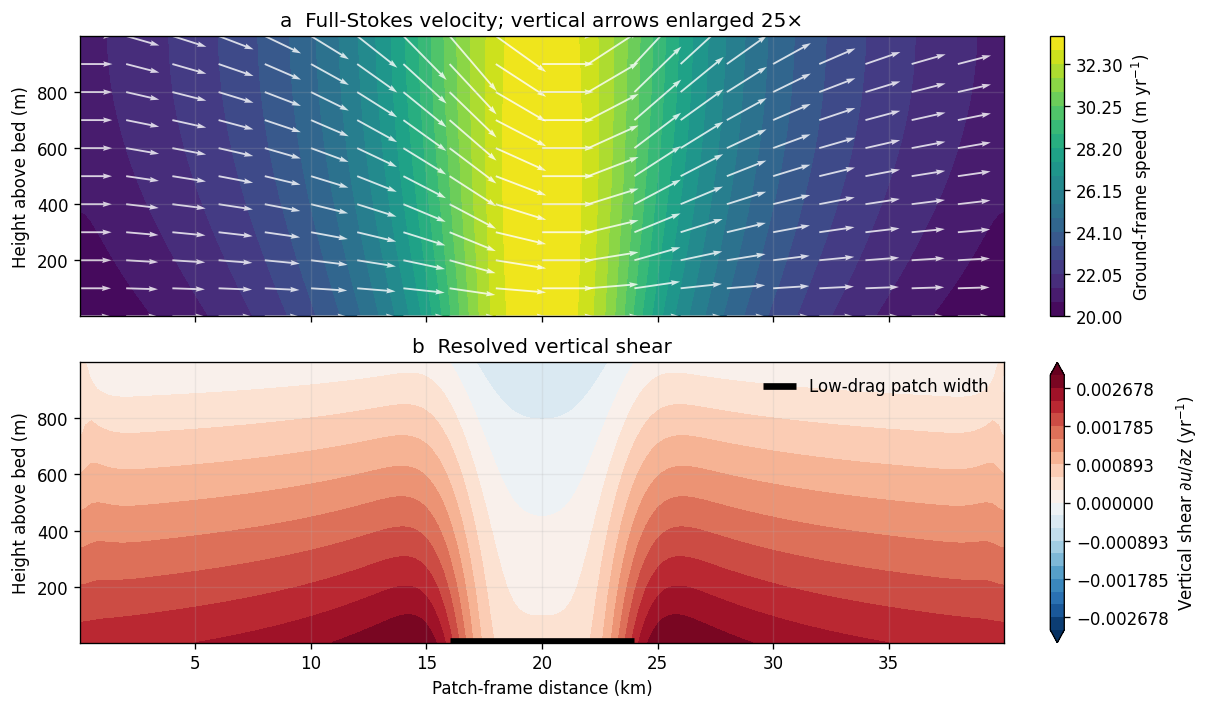

In [6]:
x_plot = np.linspace(1.0, L - 1.0, 161)
z_plot = np.linspace(1.0, H - 1.0, 41)
X, Z = np.meshgrid(x_plot, z_plot)
velocity_grid = evaluate(fine["velocity"], X, Z)
speed_grid = np.linalg.norm(velocity_grid, axis=2)
shear_grid = evaluate(fine["du_dz"], X, Z)

fig, axes = plt.subplots(2, 1, figsize=(10, 5.8), sharex=True, constrained_layout=True)
speed_levels = np.linspace(speed_grid.min(), speed_grid.max(), 21)
contour = axes[0].contourf(X / 1000, Z, speed_grid, levels=speed_levels, cmap="viridis")
skip = (slice(None, None, 4), slice(None, None, 8))
axes[0].quiver(X[skip] / 1000, Z[skip],
               velocity_grid[skip][..., 0], 25 * velocity_grid[skip][..., 1],
               color="white", alpha=0.8, scale=600, width=0.002)
fig.colorbar(contour, ax=axes[0], label=r"Ground-frame speed (m yr$^{-1}$)")
axes[0].set(ylabel="Height above bed (m)", title="a  Full-Stokes velocity; vertical arrows enlarged 25×")

limit = np.max(np.abs(shear_grid))
contour = axes[1].contourf(X / 1000, Z, shear_grid, levels=np.linspace(-limit, limit, 21),
                           cmap="RdBu_r", extend="both")
fig.colorbar(contour, ax=axes[1], label=r"Vertical shear $\partial u/\partial z$ (yr$^{-1}$)")
axes[1].plot([PATCH_CENTER / 1000 - PATCH_WIDTH / 2000,
              PATCH_CENTER / 1000 + PATCH_WIDTH / 2000], [8, 8],
             color="k", lw=4, solid_capstyle="butt", label="Low-drag patch width")
axes[1].set(xlabel="Patch-frame distance (km)", ylabel="Height above bed (m)",
            title="b  Resolved vertical shear")
axes[1].legend(frameon=False)
plt.show()

**Figure 1. Full-Stokes response to basal drag.** Panel (a) shows ground-frame speed and velocity direction on the 160 by 24-cell mesh; vertical arrows are enlarged for visibility. Panel (b) shows the resolved vertical shear, with the 8 km low-drag patch marked at the bed. The stress transfer is vertically resolved rather than reconstructed from a depth average.

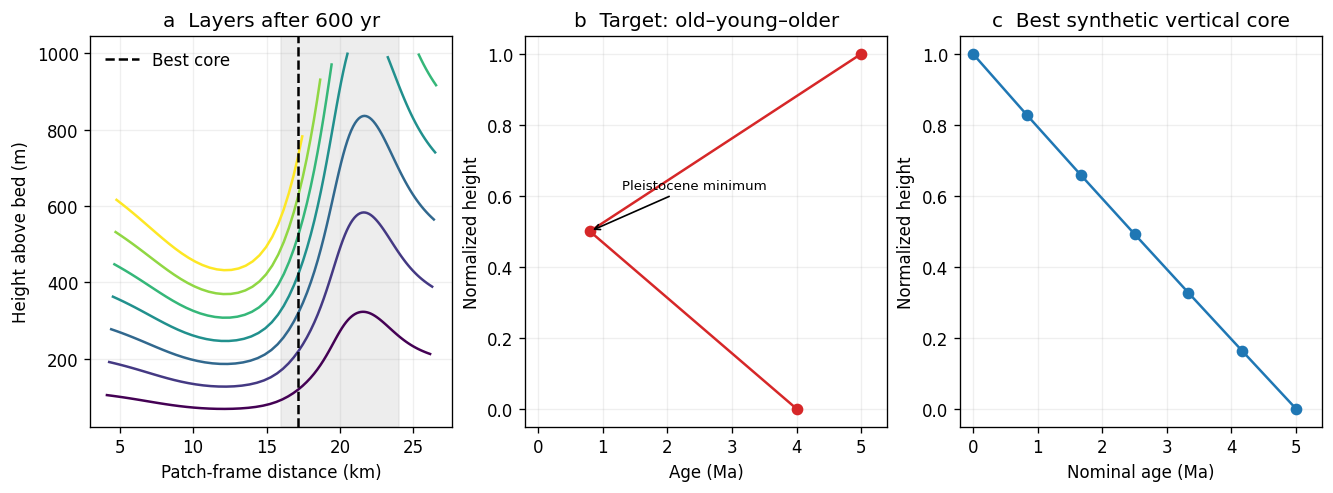

In [7]:
intersections = fine_layers["best_intersections"]
core_z = np.array([item[0] for item in intersections])
core_age = np.array([item[1] for item in intersections])
core_z_norm = (core_z - core_z.min()) / np.ptp(core_z)
target_z = np.array([1.0, 0.5, 0.0])
target_age = np.array([5.0, 0.8, 4.0])
colors = plt.cm.viridis_r(LAYER_AGES / LAYER_AGES.max())

fig, axes = plt.subplots(1, 3, figsize=(11, 4), constrained_layout=True)
for row, (age, color) in enumerate(zip(LAYER_AGES, colors)):
    axes[0].plot(fine_layers["x"][row] / 1000, fine_layers["z"][row],
                 color=color, lw=1.5)
axes[0].axvline(fine_layers["best_x"] / 1000, color="k", ls="--", label="Best core")
axes[0].axvspan((PATCH_CENTER - PATCH_WIDTH / 2) / 1000,
                (PATCH_CENTER + PATCH_WIDTH / 2) / 1000, color="0.8", alpha=0.35)
axes[0].set(xlabel="Patch-frame distance (km)", ylabel="Height above bed (m)",
            title="a  Layers after 600 yr")
axes[0].legend(frameon=False)

axes[1].plot(target_age, target_z, "o-", color="tab:red")
axes[1].annotate("Pleistocene minimum", (target_age[1], target_z[1]),
                 xytext=(1.3, 0.62), arrowprops={"arrowstyle": "->"}, fontsize=8)
axes[1].set(xlabel="Age (Ma)", ylabel="Normalized height",
            title="b  Target: old–young–older", xlim=(-0.2, 5.4), ylim=(-0.05, 1.05))

axes[2].plot(core_age, core_z_norm, "o-", color="tab:blue")
axes[2].set(xlabel="Nominal age (Ma)", ylabel="Normalized height",
            title="c  Best synthetic vertical core", xlim=(-0.2, 5.4), ylim=(-0.05, 1.05))
plt.show()

**Figure 2. Layer and vertical-core test.** Colors in (a) run from the nominal 0 Ma upper layer (yellow) to the 5 Ma lower layer (purple); gray marks the instantaneous low-drag region. The dashed core is selected by the objective age-order score. Panel (b) shows the required old–Pleistocene–older sequence, while (c) shows the best synthetic core.

## Interpretation and limitations

The vertical-core result, rather than lateral layer displacement, determines whether this scenario passes. This case fails: the patch tilts a layer to slope 0.260 but produces no overturned segment, no age-order reversal, and no Pleistocene minimum bracketed by older ice. The Waddington slope threshold is a local, instantaneous diagnostic; the integrated particle paths and explicit core intersections provide the stronger finite-strain test.

This calculation uses linear isotropic viscosity, a prescribed quasi-steady patch, fixed side profiles, and an undeformed free-surface geometry. It omits patch hydrology and thermal feedback, accumulation, anisotropy, and Allan Hills topography. Nominal ages only preserve initial order, so a successful reversal would still require a separate diffusion and chronology calculation.